<a href="https://colab.research.google.com/github/kamilakhtar015/Deep-Learning-Concepts/blob/main/homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Let's Implement Conditional Beta-VAE on MNIST Dataset")

Let's Implement Conditional Beta-VAE on MNIST Dataset


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as make_grid
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device : {device}")

using device : cuda


# Data Loading

In [5]:
# Loading the dataset and converting to tensor
train_data = datasets.MNIST(root="./data", download=True, train=True, transform=transforms.ToTensor())
test_data = datasets.MNIST(root="./data", download=True, train=False, transform=transforms.ToTensor())

print(train_data.train_data.shape)
print(test_data.test_data.shape)

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


In [6]:
# Data Loaders
train_loader = DataLoader(train_data, batch_size= 128, shuffle=True)
val_loader = DataLoader(test_data, batch_size=128, shuffle=False)

# Model Architecture

In [7]:
# from math import log
# CVAE Model
class CVAE(nn.Module):
  def __init__(self, latent_dim=2):
    super().__init__()
    self.latent_dim = latent_dim

    # Lookup table to turn a label into 16D vector
    self.embedding = nn.Embedding(10,16)

    # Encoder -> Compresses a 28x28 Image into the parameter for 2D Latent space
    self.encoder = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Flatten()
    )

    # Handles the labels and output final parameter
    self.encoder_fc = nn.Linear(128*7*7+16, 256)
    self.encoder_relu = nn.ReLU()
    self.fc_mu = nn.Linear(256, latent_dim)
    self.fc_logvar = nn.Linear(256, latent_dim)

    # Decoder -> Take a 2D point and a label and draws an image
    self.decoder_fc = nn.Sequential(
        nn.Linear(latent_dim + 16, 256),
        nn.ReLU(),
        nn.Linear(256, 128*7*7),
        nn.ReLU()
    )

    self.decoder_deconv = nn.Sequential(
        nn.ConvTranspose2d(128,64, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(64,32, kernel_size=4,stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(32,1, kernel_size=3, stride=1, padding=1)
    )

    # Initial weights
    self.init_weights()

  def init_weights(self):
    for m in self.modules():
      if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        # Initialize weights from normal distribution with small std
        nn.init.normal_(m.weight, mean=0, std=0.01)
        if m.bias is not None:
          nn.init.zeros_(m.bias)

    nn.init.zeros_(self.decoder_deconv[-1].weight)
    nn.init.zeros_(self.decoder_deconv[-1].bias)


  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar.clamp(-8,8))
    eps = torch.randn_like(std)
    return mu + eps * std

  # Full forward pass
  def forward(self, x, y):
    # Encode
    embedded_y = self.embedding(y)
    image_features = self.encoder(x)
    combined = torch.cat([image_features, embedded_y], dim=1)
    hidden = self.encoder_fc(combined)
    hidden = self.encoder_relu(hidden)
    mu = self.fc_mu(hidden)
    logvar = self.fc_logvar(hidden)

    # Reparamertrize
    z = self.reparameterize(mu, logvar)

    # Decode
    combined_z = torch.cat([z, embedded_y], dim=1)
    hidden_dec = self.decoder_fc(combined_z)
    hidden_dec_reshaped = hidden_dec.view(-1, 128, 7, 7)
    recon_logits = self.decoder_deconv(hidden_dec_reshaped)

    return recon_logits, mu, logvar

  # A separate decode function for generation task
  def decode_from_z(self, z, y):
    embedded_y = self.embedding(y)
    combined_z = torch.cat([z, embedded_y], dim=1)
    hidden_dec = self.decoder_fc(combined_z)
    hidden_dec_reshaped = hidden_dec.view(-1, 128, 7, 7)

    return torch.sigmoid(self.decoder_deconv(hidden_dec_reshaped))


# Loss Function

In [8]:
def vae_loss(recon_logits, x, mu, logvar, beta):
  # Reconstruction Loss - Binary Cross Entropy (measures how well the generated image matches the original)
  recon_loss = nn.functional.binary_cross_entropy_with_logits(recon_logits, x, reduction='sum')

  # KL Divergence -- pushes the latent space to be smooth and look like gaussian , centered cloud of points
  kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

  return (recon_loss + beta * kl_loss) / x.size(0)


# Training Loop

In [9]:
def run_training(beta_value):
  print(f"Starting Training for Beta Value : {beta_value}")
  model = CVAE().to(device)
  optimizer = optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=1e-4)

  history = {"train_loss": [], "val_loss": [],"train_recon":[], "val_recon": [], "train_kl": [], "val_kl": []}

  for epoch in range(15):
    model.train()
    # Slowly increaing the value of beta for first 8 iterations
    beta_eff = min(beta_value, beta_value * (epoch + 1)/8.0)
    train_loss, train_recon, train_kl = 0.0, 0.0, 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/15")
    for images, labels in progress_bar:
      images, labels = images.to(device), labels.to(device)

      # Forward Pass
      recon_logits, mu, logvar = model(images, labels)

      # Calculate loss
      recon_loss_bce = nn.functional.binary_cross_entropy_with_logits(recon_logits, images, reduction="sum")
      kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
      loss = (recon_loss_bce + beta_eff * kl_loss) / images.size(0)

      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer.step()

      train_loss += loss.item()
      train_recon += recon_loss_bce.item() / images.size(0)
      train_kl += kl_loss.item() / images.size(0)
      progress_bar.set_postfix(loss=loss.item())


    model.eval()
    val_loss, val_recon, val_kl = 0.0, 0.0, 0.0
    with torch.no_grad():
      for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/15 (val)"):
        images, labels = images.to(device), labels.to(device)
        recon_logits, mu, logvar = model(images, labels)

        recon_loss_bce_val = nn.functional.binary_cross_entropy_with_logits(recon_logits, images, reduction="sum")
        kl_loss_val = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = (recon_loss_bce_val + beta_value * kl_loss) / images.size(0)

        val_loss += loss.item()
        val_recon += recon_loss_bce_val.item() / images.size(0)
        val_kl += kl_loss_val.item() / images.size(0)

    history["train_loss"].append(train_loss / len(train_loader))
    history["train_recon"].append(train_recon / len(train_loader))
    history["train_kl"].append(train_kl / len(train_loader))
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_recon"].append(val_recon / len(val_loader))
    history["val_kl"].append(val_kl / len(val_loader))

  print(f"Epoch {epoch + 1} Summary : Val Loss: {history['val_loss'][-1]:.2f}, Val Recon: {history['val_recon'][-1]:.2f}, Val KL: {history['val_kl'][-1]:.2f}")

  print(f"Finished training for beta value = {beta_value}")
  model.beta = beta_value
  return model, history



In [10]:
# # Running for both beta = 1, 4
# model_b1 = run_training(1)
# model_b4 = run_training(4)

Starting Training for Beta Value : 1


Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 14/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 15/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15 Summary : Val Loss: 141.47, Val Recon: 131.97, Val KL: 2.76
Finished training for beta value = 4


# Figures

Starting Training for Beta Value : 1


Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 14/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 15/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15 Summary : Val Loss: 130.73, Val Recon: 126.97, Val KL: 4.52
Finished training for beta value = 1
Displaying figures for beta = 1


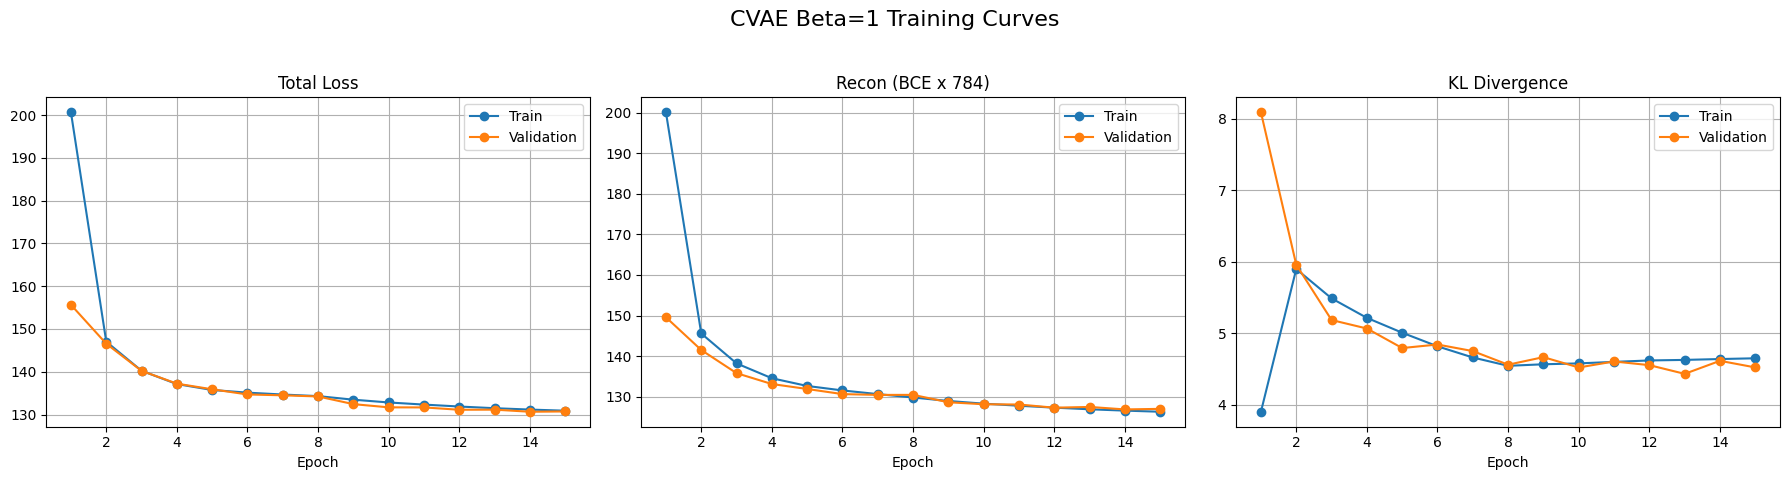

Starting Training for Beta Value : 4


Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 14/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 15/15 (val):   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15 Summary : Val Loss: 140.38, Val Recon: 130.34, Val KL: 3.04
Finished training for beta value = 4
Displaying figures for beta = 4


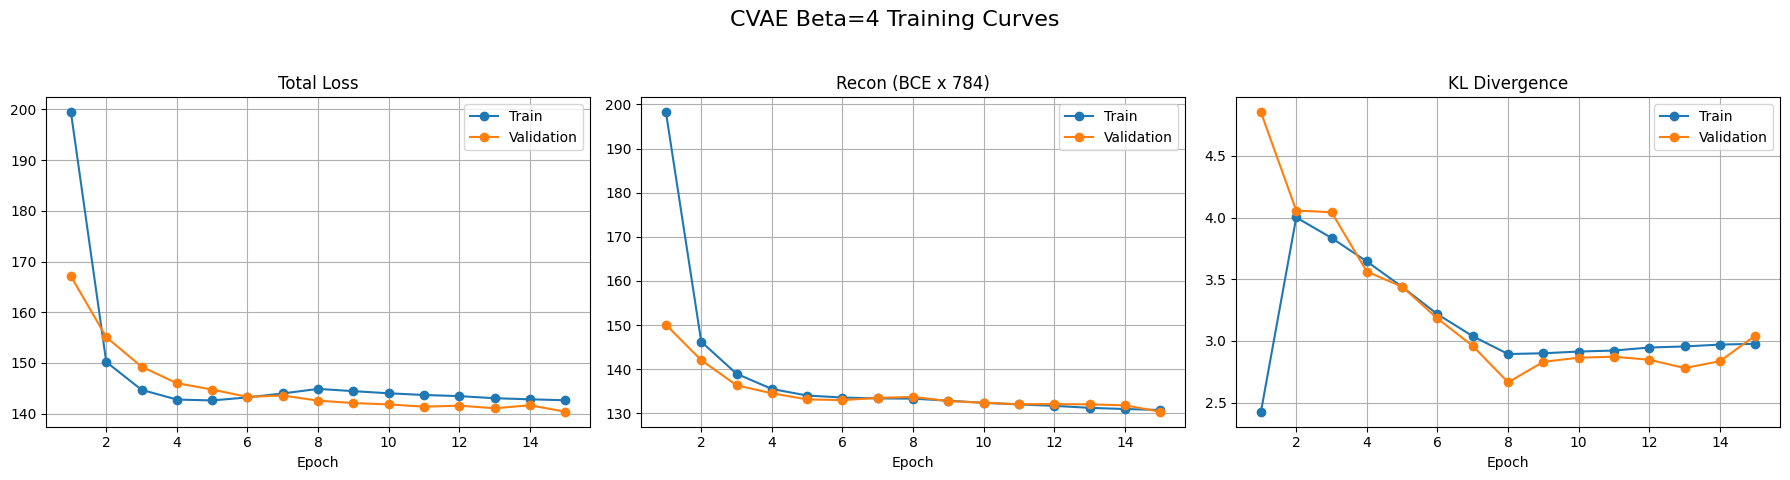

In [11]:
def plot_training_figures(history, beta):
  epochs = range(1, len(history['train_loss']) + 1)

  fig, axes = plt.subplots(1,3, figsize=(18,5))
  fig.suptitle(f"CVAE Beta={beta} Training Curves", fontsize=16)

  metrics = [
      ['loss','Total Loss'],
      ['recon', 'Recon (BCE x 784)'],
      ['kl', 'KL Divergence']
  ]

  for i, (metric, title) in enumerate(metrics):
    axes[i].plot(epochs, history[f'train_{metric}'], 'o-', label='Train')
    axes[i].plot(epochs, history[f'val_{metric}'], 'o-', label='Validation')
    axes[i].set_title(title)
    axes[i].set_xlabel('Epoch')
    axes[i].grid(True)
    axes[i].legend()

  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()


model_b1, history_b1 = run_training(beta_value=1)
print("Displaying figures for beta = 1")
plot_training_figures(history_b1, 1)

model_b4, history_b4 = run_training(beta_value=4)
print("Displaying figures for beta = 4")
plot_training_figures(history_b4, 4)


# Part 2: Reconstructions & Condition Generation

Generating Part 2 Visuals
Generating reconstructions for beta=1 model


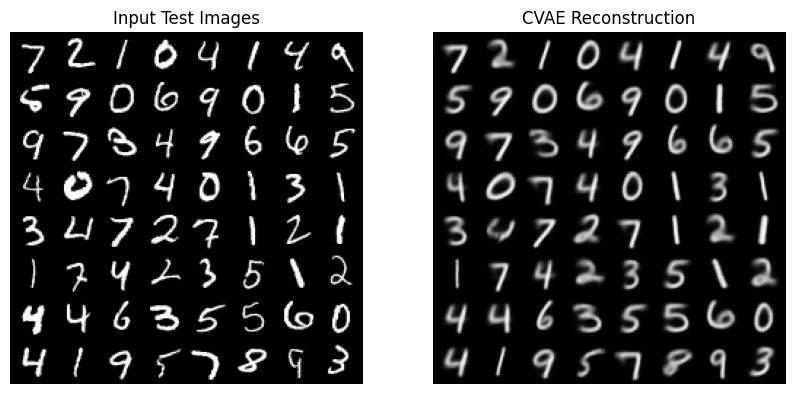


Generating new images from scartch for beta=1 model


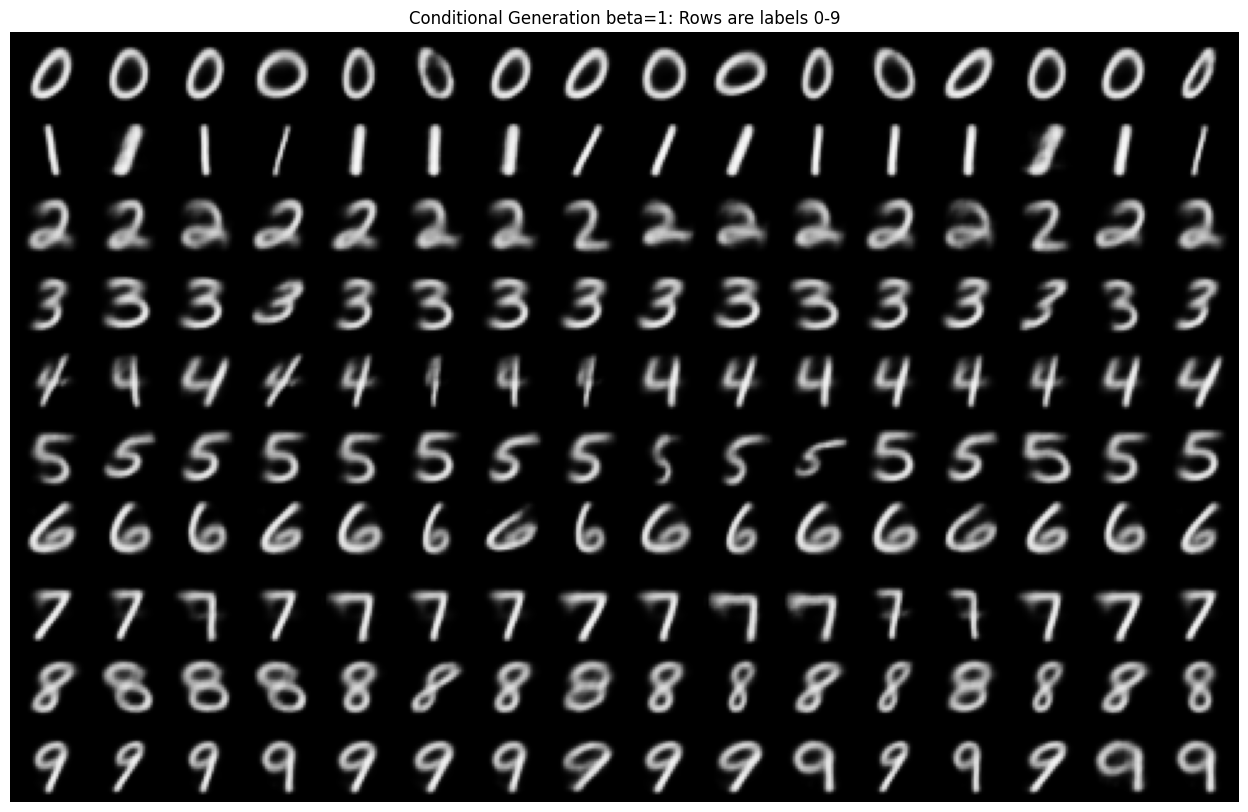

In [22]:
print("Generating Part 2 Visuals")

print("Generating reconstructions for beta=1 model")

with torch.no_grad():
  model_b1.eval()

  test_images, test_labels = next(iter(val_loader))

  test_images_subset = test_images[:64].to(device)
  test_labels_subset = test_labels[:64].to(device)

  # passing through model to get reconstructed logits
  recon_logits, _, _ = model_b1(test_images_subset, test_labels_subset)

  # apply sigmoid to get pixel values between 0 and 1
  reconstructed_images = torch.sigmoid(recon_logits)

grid_inputs = make_grid(test_images_subset.cpu(), nrow=8, padding=2)
grid_reconstructions = make_grid(reconstructed_images.cpu(), nrow=8, padding=2)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,10))

# display first grid
ax1.set_title("Input Test Images")
ax1.imshow(grid_inputs.permute(1,2,0))
ax1.axis("off")

# display second grid
ax2.set_title("CVAE Reconstruction")
ax2.imshow(grid_reconstructions.permute(1,2,0))
ax2.axis("off")

plt.show()

# Generating new images from latent space - by using latent vector z
print("\nGenerating new images from scartch for beta=1 model")

with torch.no_grad():
  model_b1.eval()

  # Sampling from normal distribution to create latent vector z
  z_samples = torch.randn(160,2).to(device)

  # creting corresponding y labels
  y_labels = torch.arange(10, device=device).repeat_interleave(16)

  # generating images from directly from z and y using decode_from_z
  generated_images = model_b1.decode_from_z(z_samples, y_labels)

grid = make_grid(generated_images.cpu(), nrow=16, padding=2)

plt.figure(figsize=(16,10))
plt.imshow(grid.permute(1,2,0))
plt.title("Conditional Generation beta=1: Rows are labels 0-9")
plt.axis("off")
plt.show()



# Part 3: Latent Space Visualization

Generating Visuals for Part 3
Plotting latent space for beta=1


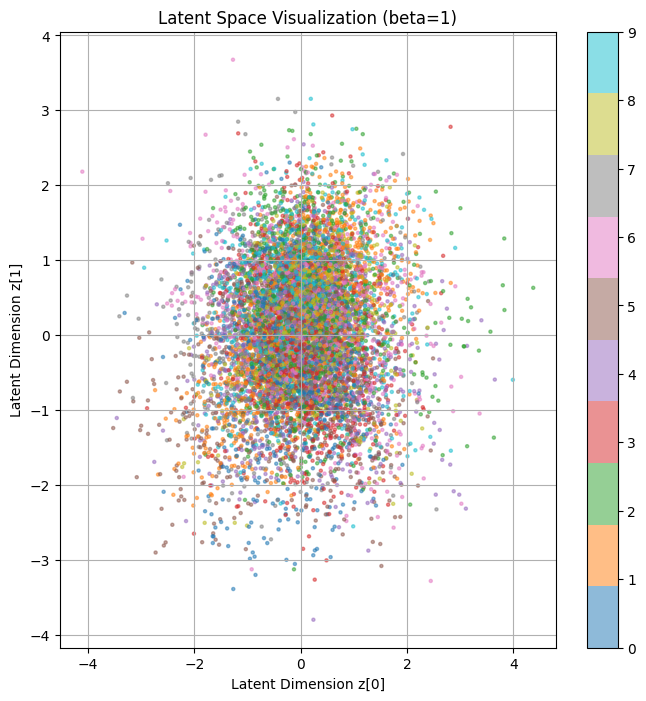

Plotting latent space for beta=4


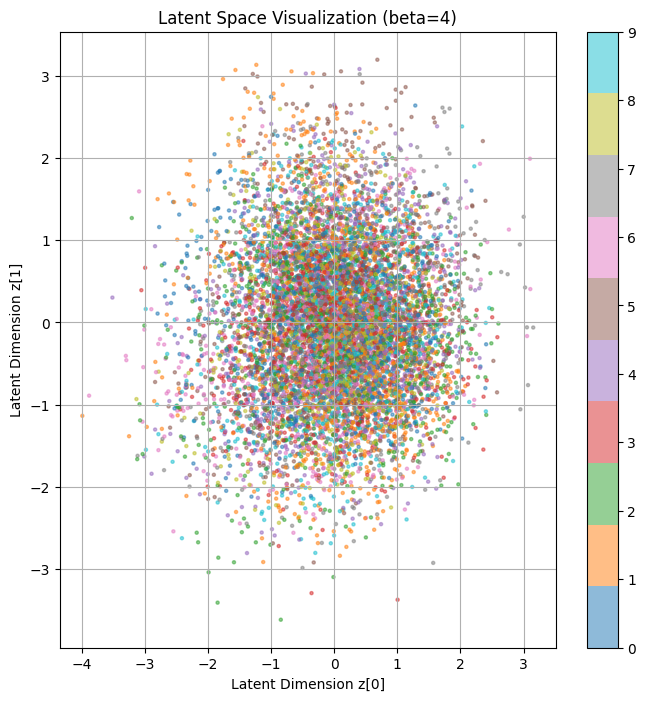

In [25]:
print("Generating Visuals for Part 3")

def plot_latent_space(model):
  print(f"Plotting latent space for beta={model.beta}")

  all_latents = []
  all_labels = []

  with torch.no_grad():
    model.eval()

    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      # for creating the latent space plot we need mu
      _, mu, _ = model(images, labels)

      all_latents.append(mu.cpu())
      all_labels.append(labels.cpu())

  latents_tensor = torch.cat(all_latents)
  labels_tensor = torch.cat(all_labels)

  plt.figure(figsize=(8,8))
  # create the scatter plot using first and second dimensions of our latent vectors
  plt.scatter(
      latents_tensor[:, 0],
      latents_tensor[:, 1],
      c=labels_tensor,
      cmap="tab10",
      s=5,
      alpha=0.5
  )

  plt.colorbar(ticks=range(10))
  plt.title(f"Latent Space Visualization (beta={model.beta})")
  plt.xlabel("Latent Dimension z[0]")
  plt.ylabel("Latent Dimension z[1]")
  plt.grid(True)
  plt.show()


plot_latent_space(model_b1)
plot_latent_space(model_b4)


# Comments on Cluster Separation

1- CVAE with beta=1
The districution is spread out, extending roughly from -3 to +3. Showing the model is using large area of latent space.

The colors are almost completely mixed together. It is very difficult to see any distinct cluster. This indicated that while the model can reconstruct the digits, its internal map is not well organized by class.

2- CVAE with beta=2
The distribution is spread out in this case too, extending roughly from -2 to +2, means taking smaller area compare to beta=1. So, increasing the beta value is making the KL Divergence stronger and forcing the encoder to produce distribution much closer to the standard normal prior (N(0,I)).

The points are not still perfectly separated, the organization is slightly better than beta=1 plot. The model was forced to organize the latent space more efficiently to both satisfy the stronger KL penalty and still be able to reconstruct the images.

# Part 4: Latent Traversals & Manifold


 Generating Visuals for Part 4
Generating traversals for beta=1


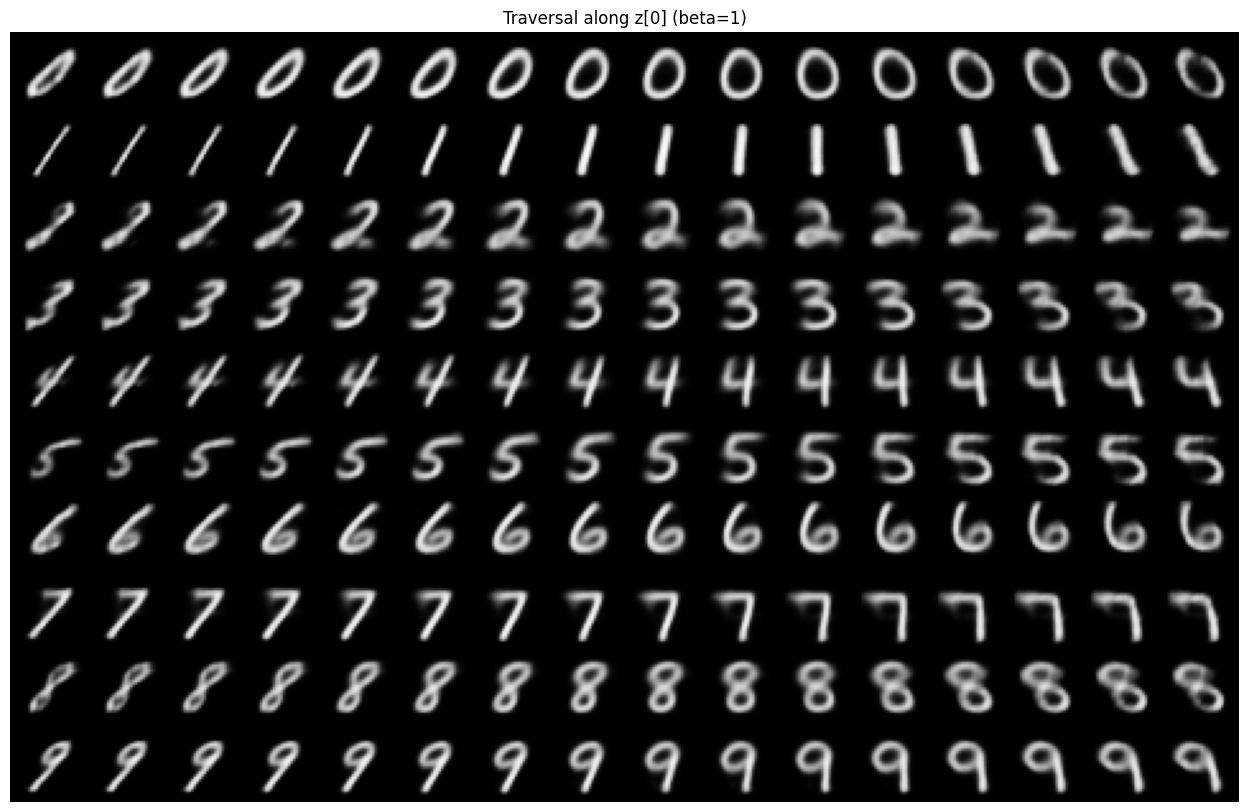

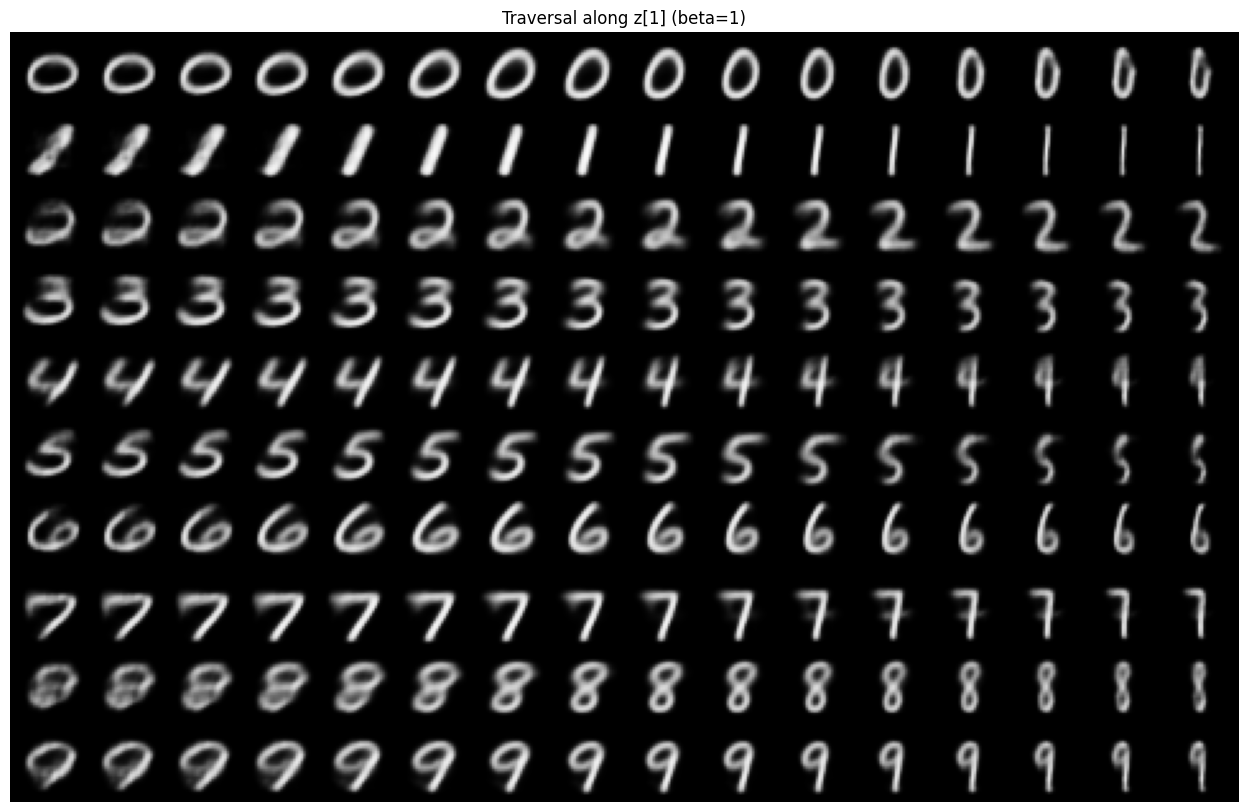

Generating traversals for beta=4


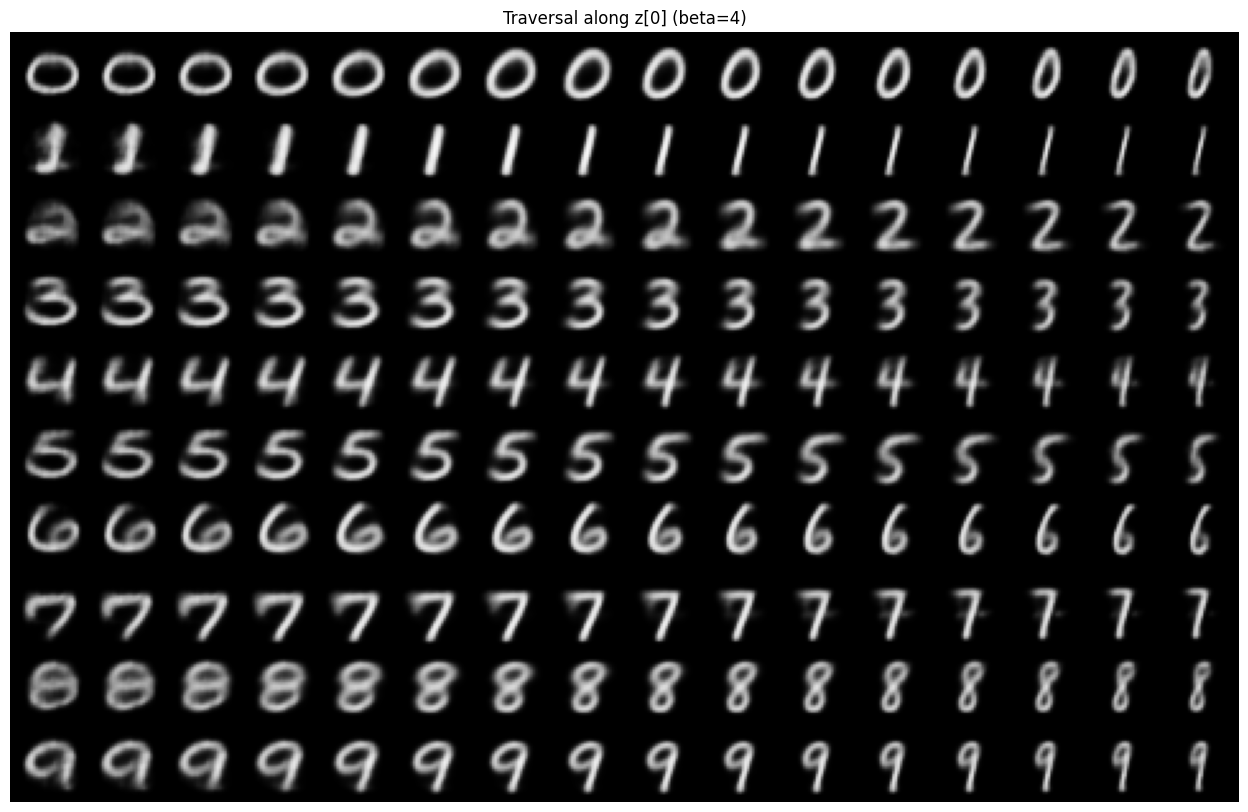

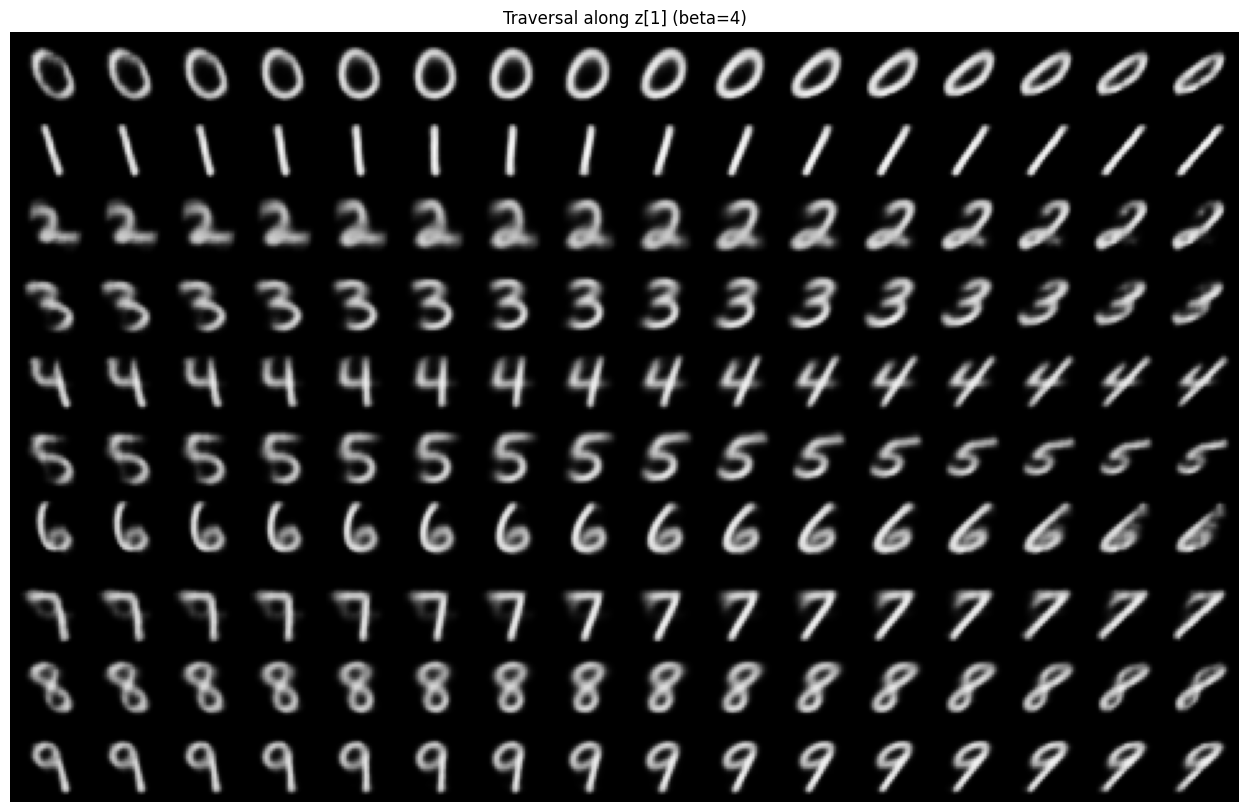

Generating manifold for digit '0 (beta=1)'


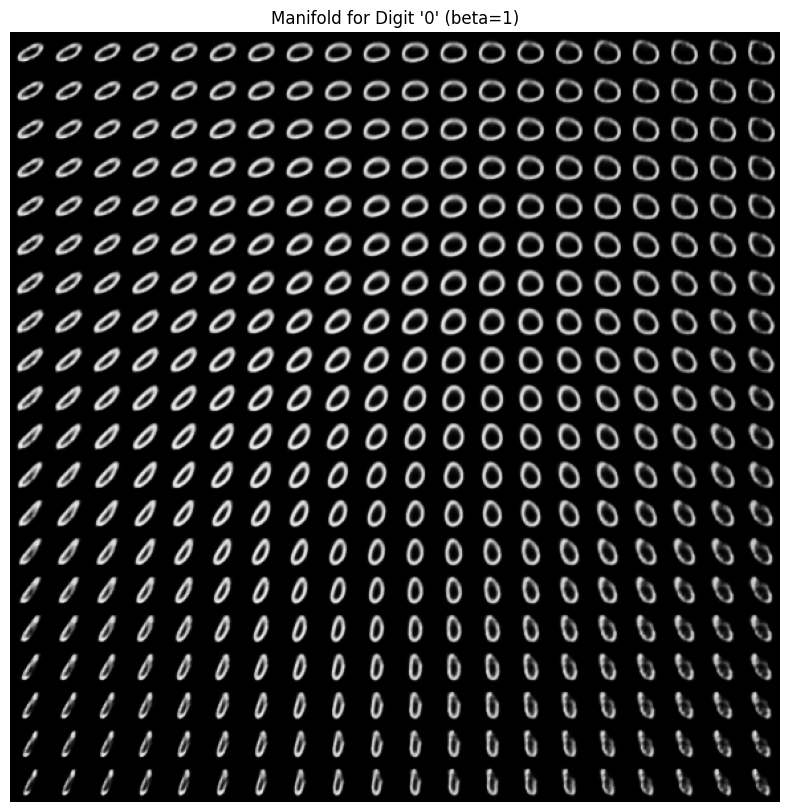

Generating manifold for digit '0 (beta=4)'


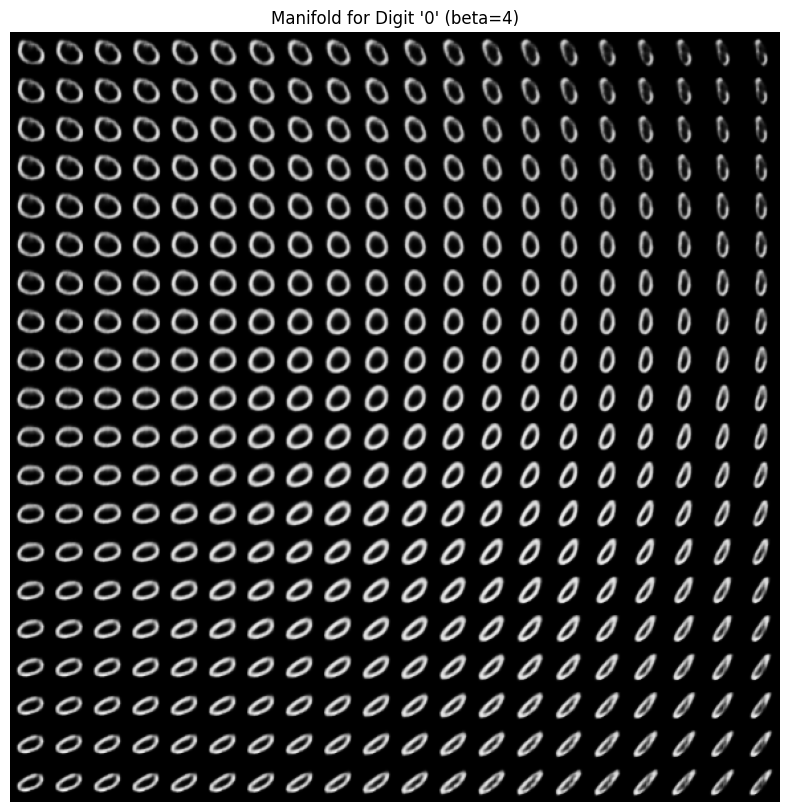

In [27]:
print("\n Generating Visuals for Part 4")

def plot_traversals(model):
  print(f"Generating traversals for beta={model.beta}")

  with torch.no_grad():
    model.eval()
    #
    sweep = torch.linspace(-3,3,16).to(device)
    y_labels = torch.arange(10).repeat_interleave(16).to(device)

    # Traverse z[0] - creating latent vectors
    z0_vectors = torch.zeros(160, 2, device=device)
    z0_vectors[:, 0] = sweep.repeat(10)
    images_z0 = model.decode_from_z(z0_vectors, y_labels)

    # Traverse z[1]
    z1_vectors = torch.zeros(160, 2, device=device)
    z1_vectors[:, 1] = sweep.repeat(10)
    images_z1 = model.decode_from_z(z1_vectors, y_labels)

  grid_z0 = make_grid(images_z0.cpu(), nrow=16, padding=2)
  plt.figure(figsize=(16, 10))
  plt.imshow(grid_z0.permute(1,2,0))
  plt.title(f"Traversal along z[0] (beta={model.beta})")
  plt.axis("off")
  plt.show()

  grid_z1 = make_grid(images_z1.cpu(), nrow=16, padding=2)
  plt.figure(figsize=(16,10))
  plt.imshow(grid_z1.permute(1,2,0))
  plt.title(f"Traversal along z[1] (beta={model.beta})")
  plt.axis("off")
  plt.show()

plot_traversals(model_b1)
plot_traversals(model_b4)


# Latent manifold - create a full 2D grid of latent vectors to get a complete "map"
def plot_manifold(model, digit=0):
  print(f"Generating manifold for digit '{digit} (beta={model.beta})'")
  with torch.no_grad():
    model.eval()

    grid_size=20
    axis_range = torch.linspace(-3,3, grid_size)

    grid_x, grid_y = torch.meshgrid(axis_range, axis_range, indexing="xy")
    z_grid = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1).to(device)
    y_grid = torch.full((grid_size**2,), digit, device=device)
    manifold_images = model.decode_from_z(z_grid, y_grid)


  grid = make_grid(manifold_images.cpu(), nrow=grid_size, padding=1)
  plt.figure(figsize=(10,10))
  plt.imshow(grid.permute(1,2,0))
  plt.title(f"Manifold for Digit '{digit}' (beta={model.beta})")
  plt.xlabel("Latent Dimension 1 (z[0])")
  plt.ylabel("Latent Dimension 2 (z[1])")
  plt.axis("off")
  plt.show()

plot_manifold(model_b1, digit=0)
plot_manifold(model_b4, digit=0)

